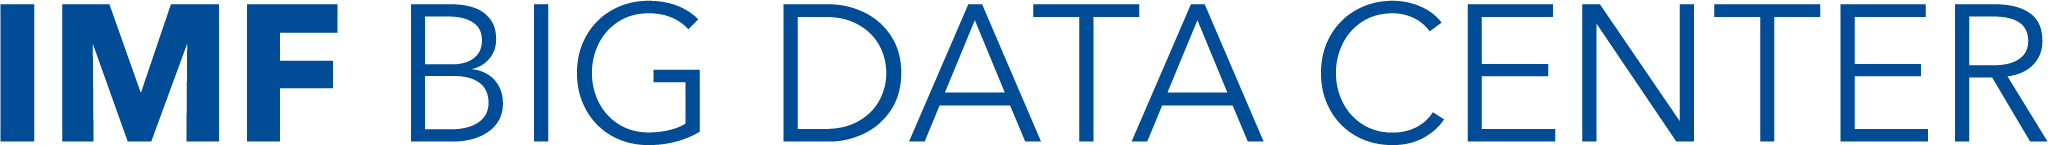

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/imfgit/imf_big_data_workshop_sti26/blob/main/notebooks/BDC_Text_Classification.ipynb)

# Text Classification in Practice

---

<br>**Contributors:** [Mario Saraiva](msaraiva@imf.org), [Alberto Sanchez](asanchez3@imf.org)
<br> **Last update:** 2025-10-19 (Created: 2025-May)
<br> **Description:** This notebook showcases text analysis in practice and is organized into three main sections: (1) dataset overview and data cleaning, (2) Applying machine learning for text classification, and (3) an assessment of the model results and proposed advanced models and discussion questions.
<br> **References:**

<h3> <b> Problem statement: Text-Classification of financial transactions </b>

This is a *real* case example and the country identifiers have been annonymized. The goal is to use this example to reflect on common classification issues faced in our day-to-day work.

**Objective**
- i.	Classifying the transactions into two groups, i.e., BOP-transactions or non-BOP transactions, based on factors like residency of the parties to the transactions, change of ownership, direction of flows, origin and destinations of flows etc; and

- ii.	Categorising each of the BOP-determined transactions to pre-existing set of codes, which ultimately determines under which BOP Accounts the transactions can be aggregated.
---


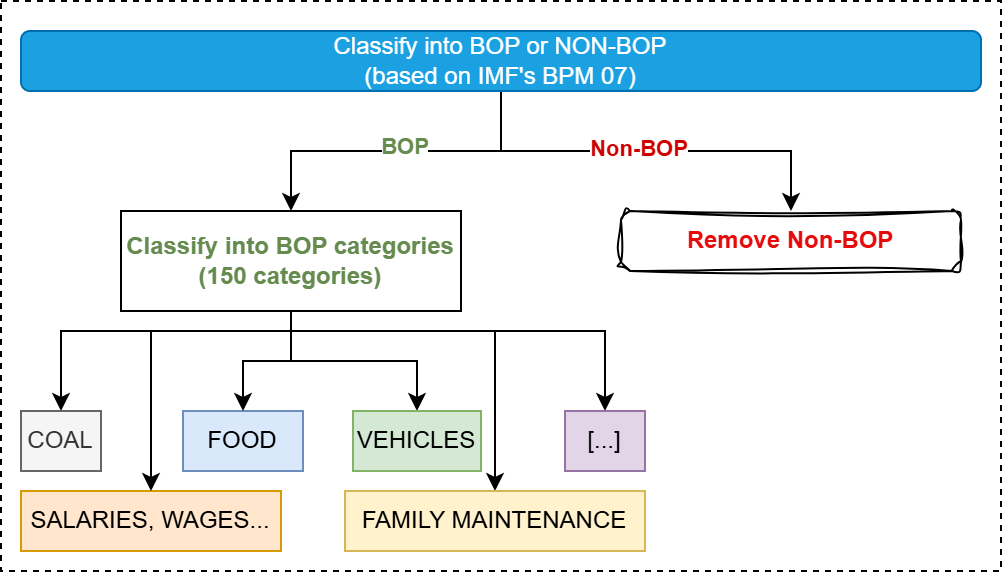

## Set up

### Import Libraries

In [1]:
import os
import re
import time
import random
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import PlaintextCorpusReader
nltk.download('punkt')
nltk.download('punkt_tab')

import matplotlib.pyplot as plt
import matplotlib.cm as cm

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Mount Google Drive

In [2]:
# #If using Google Colab
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


### Helper functions

Plot confusion matrix

In [10]:
def plot_top_confusion_matrix(y_true, y_pred, top_n=20, use_codes=False, label_to_code=None):
    """
    Plots a confusion matrix for the top-N most frequent classes in y_true.

    Args:
        y_true (list or array): Ground truth labels.
        y_pred (list or array): Predicted labels.
        top_n (int): Number of most frequent classes to include.
        use_codes (bool): Whether to display label codes instead of raw labels.
        label_to_code (dict): Optional dictionary mapping labels to codes.
    """

    # Step 1: Identify the top-N most frequent true labels
    most_common = [label for label, _ in Counter(y_true).most_common(top_n)]

    # Step 2: Filter y_true and y_pred to only include samples where y_true is in top-N
    mask = [y in most_common for y in y_true]
    y_true_filtered = np.array(y_true)[mask]
    y_pred_filtered = np.array(y_pred)[mask]

    # Step 3: Replace predictions not in top-N with a placeholder
    y_pred_filtered = [y if y in most_common else "__other__" for y in y_pred_filtered]

    # Step 4: Compute the confusion matrix
    cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=most_common)

    # Step 5: Prepare axis labels
    if use_codes and label_to_code:
        short_labels = [label_to_code.get(label, label) for label in most_common]
    else:
        # Truncate long labels and append ellipsis
        short_labels = [label[:top_n] + '…' if len(label) > 20 else label for label in most_common]

    # Step 6: Plot the confusion matrix as a heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=short_labels, yticklabels=short_labels)

    # Step 7: Decorate the plot
    plt.title(f"Confusion Matrix (Top {top_n} Classes)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# def plot_top_confusion_matrix(y_true, y_pred, top_n=20, use_codes=False, label_to_code=None):
#     """
#     Plots a confusion matrix for the top-N most frequent classes in y_true.

#     Args:
#         y_true (list or array): Ground truth labels.
#         y_pred (list or array): Predicted labels.
#         top_n (int): Number of most frequent classes to include.
#         use_codes (bool): Whether to display label codes instead of raw labels.
#         label_to_code (dict): Optional dictionary mapping labels to codes.
#     """

#     # Step 1: Identify the top-N most frequent true labels
#     most_common = [label for label, _ in Counter(y_true).most_common(top_n)]

#     # Step 2: Filter y_true and y_pred to only include samples where y_true is in top-N
#     mask = [y in most_common for y in y_true]
#     y_true_filtered = np.array(y_true)[mask]
#     y_pred_filtered = np.array(y_pred)[mask]

#     # Step 3: Replace predictions not in top-N with a placeholder
#     y_pred_filtered = [y if y in most_common else "__other__" for y in y_pred_filtered]

#     # Step 4: Compute the confusion matrix
#     # Need to include "__other__" in labels if it was added to y_pred_filtered
#     labels_for_cm = most_common
#     if "__other__" in y_pred_filtered:
#         labels_for_cm = most_common + ["__other__"]

#     cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=labels_for_cm)

#     # Step 5: Prepare axis labels - Convert labels to string before processing
#     if use_codes and label_to_code:
#         short_labels = [str(label_to_code.get(label, label)) for label in labels_for_cm]
#     else:
#         # Truncate long labels and append ellipsis - Convert to string first
#         short_labels = [str(label)[:20] + '…' if isinstance(label, (str, int)) and len(str(label)) > 20 else str(label) for label in labels_for_cm]


#     # Step 6: Plot the confusion matrix as a heatmap
#     plt.figure(figsize=(12, 10))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                 xticklabels=short_labels, yticklabels=short_labels)

#     # Step 7: Decorate the plot
#     plt.title(f"Confusion Matrix (Top {top_n} Classes)")
#     plt.xlabel("Predicted")
#     plt.ylabel("Actual")
#     plt.tight_layout()
#     plt.show()



Summary report of key performance metrics

In [12]:
def summarize_classification_report(y_true, y_pred, label):
    """
    Summarizes a classification report into key metrics and class-level performance insights.

    Args:
        y_true (list/array): Ground truth class labels.
        y_pred (list/array): Predicted class labels.
        label (str): Model label or identifier (used in the output dictionary).

    Returns:
        insights (dict): Dictionary containing accuracy, macro F1, weighted F1,
                         underperforming and good-performing classes.
        report (dict): Full classification report as a dictionary.
    """
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    # Extract overall metrics
    accuracy = report.get("accuracy", np.nan)
    macro_f1 = report.get("macro avg", {}).get("f1-score", np.nan)
    weighted_f1 = report.get("weighted avg", {}).get("f1-score", np.nan)

    underperforming = []
    goodperforming = []

    # Evaluate per-class performance
    for cls_label, metrics in report.items():
        if not isinstance(metrics, dict):
            continue  # Skip non-class entries like "accuracy"

        support = metrics.get("support", 0)
        f1 = metrics.get("f1-score", 0)

        # Filter classes with at least 5 examples
        if support >= 5:
            if f1 < 0.3:
                underperforming.append((cls_label, f1))
            elif f1 >= 0.7:
                goodperforming.append((cls_label, f1))

    # Fallback if no classes matched thresholds
    if not goodperforming:
        goodperforming = [("None", 0.0)]
    if not underperforming:
        underperforming = [("None", 0.0)]

    # Assemble summary
    insights = {
        "model": label,
        "accuracy": round(accuracy, 2),
        "macro_f1": round(macro_f1, 2),
        "weighted_f1": round(weighted_f1, 2),
        "underperforming_classes": sorted(underperforming, key=lambda x: x[1]),
        "goodperforming_classes": sorted(goodperforming, key=lambda x: -x[1])
    }

    return insights, report

Train and evaluate the model

In [13]:
def train_evaluate_model(model, X_train, X_test, y_train, y_test, top_n, label="Model",
                         use_codes=False, label_to_code=None, full_report=False):
    """
    Trains a classification model, evaluates it using classification metrics,
    and visualizes the top-N class confusion matrix.

    Args:
        model         : A scikit-learn classifier (e.g., SVC(), LogisticRegression())
        X_train       : Training features
        X_test        : Testing features
        y_train       : Training labels
        y_test        : Testing labels
        top_n         : Number of most frequent classes to display in confusion matrix
        label         : Name or identifier for the model (used in report summaries)
        use_codes     : Whether to map class labels to codes in the confusion matrix
        label_to_code : Dictionary mapping labels to codes (used if use_codes=True)

    Returns:
        insights (dict) : Summary dictionary with accuracy, macro F1, weighted F1, and class performance
        report (dict)   : Full classification report dictionary (from sklearn)
    """

    print(f"\n🔍 Evaluating Model: {label}")

    # === Train the model ===
    model.fit(X_train, y_train)

    # === Predict on test data ===
    y_pred = model.predict(X_test)

    # === Print full classification report ===

    if full_report:
        print("\n📊 Classification Report:")
        print(classification_report(y_test, y_pred))
    else:
        print("\n📊 Classification Report (Summary):")

    # === Summarize key insights ===
    insights, report = summarize_classification_report(y_test, y_pred, label)

    # === Print summary metrics ===
    print(f"\n📈 Accuracy: {insights['accuracy']}")
    print(f"Macro F1 Score: {insights['macro_f1']}")
    print(f"Weighted F1 Score: {insights['weighted_f1']}")

    # === Underperforming classes (F1 < 0.3) ===
    print("\n❌ Underperforming Classes (F1 < 0.3):")
    for cls, score in insights["underperforming_classes"]:
        print(f"  - {cls}: F1 = {score:.2f}")

    # === Well-performing classes (F1 ≥ 0.7) ===
    print("\n✅ Well-performing Classes (F1 ≥ 0.7):")
    for cls, score in insights["goodperforming_classes"]:
        print(f"  - {cls}: F1 = {score:.2f}")

## TODO: Fix y_test and y_pred to include labels as well as codes

    # # === Plot confusion matrix for top N classes ===
    # plot_top_confusion_matrix(
    #     y_test,
    #     y_pred,
    #     top_n=top_n,
    #     use_codes=use_codes,
    #     label_to_code=label_to_code
    # )

    return insights, report

Normalize and clean Data Frame structure: columns, etc.

In [14]:
def normalize(alias_map, col):
    # Basic cleanup
    col = col.strip()
    col = col.replace(" ", "_")
    col = re.sub(r"[^\w_]", "", col)
    col = col.lower()

    # Domain-specific alias substitution
    for key, alias in alias_map.items():
        if key in col:
            return alias

    return col

def clean_column_names(columns):
    """
    Standardizes a list of column names:
    - Trims whitespace
    - Replaces spaces with underscores
    - Removes special characters
    - Applies consistent lowercase formatting
    - Applies domain-specific aliases

    Args:
        columns (list of str): Original column names

    Returns:
        list of str: Cleaned and standardized column names
    """

    # Domain-specific replacements (aliases)
    alias_map = {
        "customers_description": "cdt",
        "description_of_transcation": "dot",
        "description_of_transaction": "dot",
        "code_of_transcation": "tcode",
        "code_of_transaction": "tcode"
    }

    return [normalize(alias_map, col) for col in columns]


Text cleaning

In [15]:
import string
import unicodedata
import re

def sanitize_text_simple(text):
    """
    Cleans text by:
    - Converting non-strings to string
    - Removing accents
    - Lowercasing
    - Removing punctuation, numbers
    - Collapsing extra whitespace
    """
    if not isinstance(text, str):
        text = str(text)

    # Remove accents and normalize unicode
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

    # Lowercase
    text = text.lower()

    # Remove punctuation and digits
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\d+", "", text)

    # Normalize whitespace
    return re.sub(r"\s+", " ", text).strip()


### Load the data

<h3> ⏰ Don't forget to adjust the path </h3>

In [4]:
ROOT = '/content/drive/MyDrive/STI 2026/' #if using colab

workspace = "Day 4 - Text Analytics/"
data_folder = "Data"
folder = os.path.join(ROOT, workspace, data_folder)
os.path.exists(folder)

True

In [5]:
###Sample transactions
filename = 'Transactions_data.xlsx'
filepath = os.path.join(folder, filename)
df_a_raw = pd.read_excel(filepath, sheet_name = "Form A Sample Inc")
# df_s_raw = pd.read_excel(filepath, sheet_name = "Form S Sample Inc")

df_a = df_a_raw.copy()

###Transaction codes
filepath2 = os.path.join(folder, 'ITRS_codes.xlsx')
df_codes_1 = pd.read_excel(filepath2, sheet_name='DEBITS_CODES')
# df_codes_2 = pd.read_excel(filepath2, sheet_name='CREDITS_CODES')
# df_codes_3 = pd.read_excel(filepath2, sheet_name='COMM BANKS CODES')

### Data description

In [6]:
display(df_a.head(5))
display(df_codes_1.head(5))

,Bank,Code of Currency for bookkeeping Account,Code of Country for bookkeeping Account,Date of Transaction,Debit Amount (Foreign),Debit Amount (Local),Credit Amount (Foreign),Credit Amount (Foreign)2,Exchange Rate,Customers Description - (Purpose of Transaction),Description of Transcation,Code of Transaction,CODE+DESC,MERCHANDISE/SERVICES/OTHER,Code of Partner Country
0,Bank 3,USD,US,2025-01-24 00:00:00,29710.53,420233.80,NaN,NaN,0.0707,NaN,DIAMONDS,1101,1101DIAMONDS,1.MERCHANDISE,US
1,Bank 4,ZAR,ZA,2025-01-10 00:00:00,259776.00,192740.76,NaN,NaN,0.7419,289,DIAMONDS,1101,1101DIAMONDS,1.MERCHANDISE,ZA
2,Bank 4,ZAR,ZA,2025-01-23 00:00:00,801552.39,600143.76,NaN,NaN,0.7487,See payment advice note from 23 01,DIAMONDS,1101,1101DIAMONDS,1.MERCHANDISE,ZA
3,Bank 4,ZAR,ZA,2025-01-31 00:00:00,167020.60,124968.95,NaN,NaN,0.7482,See payment advice note from 31 01,DIAMONDS,1101,1101DIAMONDS,1.MERCHANDISE,ZA
4,Bank 3,USD,US,2025-01-22 00:00:00,25400.53,361316.22,NaN,NaN,0.0703,NaN,DIAMONDS,1101,1101DIAMONDS,1.MERCHANDISE,IN


,PURPOSE,CODE
0,DIAMONDS,1101
1,COAL,1102
2,COPPER AND NICKEL,1103
3,MEAT AND MEAT PRODUCTS,1104
4,TEXTILES,1106


In [7]:
display(df_a.count())

,0
Bank,8464
Code of Currency for bookkeeping Account,8464
Code of Country for bookkeeping Account,8438
Date of Transaction,8464
Debit Amount (Foreign),8464
Debit Amount (Local),8464
Credit Amount (Foreign),3452
Credit Amount (Foreign)2,3362
Exchange Rate,8464
Customers Description - (Purpose of Transaction),7733


### **BPM7 Classification Rules**

**Check Country and Currency:**

1.   If the Code of Country for Bookkeeping Account (Column 3) or Code of Partner Country (Column 15) indicates a foreign country, this indicates a potential BoP transaction.
2.   Transactions with foreign currency exchange (e.g., Debit Amount (Foreign), Credit Amount (Foreign)) are typically part of the BoP, since they involve cross-border flows.

---

**About the dataset**:  
- *Transaction (ITRS) data that is used to generate Balance of Payment (BOP) statistics. The processing of the data is very manual and time consuming.*

- *The worksheet **“Form A Sample Inc”** contains outgoing transactions (domestic residents sending to the rest of the world) where columns 11 to 13 are highlighted in green, representing the final transformed data. Column 11 is processed based on Column 10, and this is where the bulk of the challenge comes from, that is, **transforming the customer's purpose of transaction into the BOP [categories]**. Worksheet “Form S Sample Inc” contains incoming transactions (from the rest of the world to domestic residents.)*

---
**KEY DATASET COLUMNS**
* [INPUT]   - Column 10 = Customers Description - (Purpose of Transaction)
* [OUTPUT] - Column 11 = Description of Transcation [Category]
* [OUTPUT] - Column 12 = Code of Transaction [Category Code]


## Data processing

### Standardize column names

It is a good practice to standardize column names in a dataset because it:

- **Prevents bugs due to inconsistent column names**

 - For example, " Code of Transaction ", "code_of_transaction", and "Code_of_Transcation" would all become "tcode".

- **Makes code maintainable and readable**

  - You can reliably refer to "tcode" instead of checking for multiple variants throughout your code.

- **Improves compatibility with pandas**

  - Spaces and special characters in column names can lead to errors or require awkward syntax (e.g., df['Column Name'] vs df.column_name).

In [8]:
df_a.columns

Index(['Bank ', 'Code of Currency for bookkeeping Account',
       'Code of Country for bookkeeping Account', 'Date of Transaction',
       'Debit Amount (Foreign)', 'Debit Amount (Local)',
       'Credit Amount (Foreign)', 'Credit Amount (Foreign)2', 'Exchange Rate',
       'Customers Description - (Purpose of Transaction)',
       'Description of Transcation', 'Code of Transaction', 'CODE+DESC',
       'MERCHANDISE/SERVICES/OTHER', 'Code of Partner Country'],
      dtype='object')

<H4> Key columns: </H4>

- 'cdt' = Customer Description of Transaction (user's input)

- 'dot' = Description of Transaction (Classification output)

- 'tcode' = Transaction Code (Classification output)

In [16]:
#Clean col names
df_a.columns = clean_column_names(df_a.columns)
print(f"New column names:\n {df_a.columns}")

# Apply strip() to all string values in the DataFrame (i.e. remove leading and trailing white spaces)
df_a = df_a.map(lambda x: x.strip() if isinstance(x, str) else x)

#Fill missing descriptions with "Not Provided"
df_a['cdt'] = df_a['cdt'].fillna('Not Provided').astype(str)

print('\nSample transactions from Form A:\n - Customer Description of Transaction (cdt) and Description of Transaction (dot)')
df_a[['cdt', 'dot', 'tcode']].sample(10)

New column names:
 Index(['bank', 'code_of_currency_for_bookkeeping_account',
       'code_of_country_for_bookkeeping_account', 'date_of_transaction',
       'debit_amount_foreign', 'debit_amount_local', 'credit_amount_foreign',
       'credit_amount_foreign2', 'exchange_rate', 'cdt', 'dot', 'tcode',
       'codedesc', 'merchandiseservicesother', 'code_of_partner_country'],
      dtype='object')

Sample transactions from Form A:
 - Customer Description of Transaction (cdt) and Description of Transaction (dot)


,cdt,dot,tcode
7226,MT103/REMTDR/ SALARIES,"SALARIES, WAGES, ALLOWANCES AND DIRECTORS' FEES",1301
1380,BC LM to Petre Gaz Advance,FUEL,1111
6560,nile,MINING RELATED SERVICES,1265
3619,J Haskins,OTHER GOODS,1113
8374,Osman,DEPOSITS ABROAD-NON-BANK FINANCIAL INSTITUTION...,1855
5845,PYMT_DTL_1 Payment for the Tuition fee,EDUCATION RELATED EXPENDITURE,1223
4237,MERCHANDISE IMPORTS,OTHER GOODS,1113
7718,09-Other Services~695 - All other services~MUT...,TRANSFERS BETWEEN MTOs,1411
4341,24RU-DEN03-1220,OTHER GOODS,1113
8334,/CCTFDR/ CROSS BORDE...,DEPOSITS ABROAD-NON-BANK FINANCIAL INSTITUTION...,1855


### Classify into BOP or non-BOP

* Make sure all observations are potentially BOP transactions by applying the rules described above to classify BOP7.
* The dataset has been annonymized. Consider **'MY'** as our country code (the one generating the BOP).

In [17]:
domestic_country_codes = ['MY']
# === Check for Foreign Country Involvement ===
df_a['Foreign_Country_Involved'] = ~df_a['code_of_country_for_bookkeeping_account'].isin(domestic_country_codes) | \
                                 ~df_a['code_of_partner_country'].isin(domestic_country_codes)

# === Check for Foreign Currency Involvement through transaction amount ===
df_a['Foreign_Currency_Transaction'] = (df_a['debit_amount_foreign'].fillna(0) != 0) | \
                                     (df_a['credit_amount_foreign'].fillna(0) != 0)

# === Determine Potential BoP Transaction ===
df_a['Potential_BoP_Transaction'] = df_a['Foreign_Country_Involved'] | df_a['Foreign_Currency_Transaction']

bop_counts = df_a['Potential_BoP_Transaction'].value_counts()
print(bop_counts)
print(f"\nProportion of True values: {bop_counts.get(True, 0) / len(df_a_raw):.4f}")

Potential_BoP_Transaction
True    8464
Name: count, dtype: int64

Proportion of True values: 1.0000


### Data summarization

In [18]:
# Ensure 'cdt' column is lowercase
df_a['cdt'] = df_a['cdt'].apply(lambda x: x.lower() if isinstance(x, str) else x)

# Filter out rows where 'cdt' is 'Not Provided'
df_filtered = df_a[df_a['cdt'] != 'Not Provided'].copy()

# Create new column for unique lowercased 'cdt' values (if not already done)
df_filtered['cdt_lower'] = df_filtered['cdt']

# Group by 'dot' to count unique terms and collect the unique values
agg_by_dot = df_filtered.groupby('dot').agg(
    code = ('tcode', 'first'),
    term_count=('cdt', 'nunique'),
    cdt_unique_terms=('cdt_lower', lambda x: list(set(x)))
).reset_index()

# Compute percentage distribution of 'dot' values
dot_distribution = (
    df_a['dot'].value_counts(normalize=True)
    .mul(100).round(4).rename('pct')
    .reset_index()
    .rename(columns={'index': 'dot'})
)

# Merge aggregated data with percentage distribution
summary_df = pd.merge(agg_by_dot, dot_distribution, on='dot', how='left')

# Sort by descending percentage
summary_df = summary_df.sort_values('pct', ascending=False).reset_index(drop=True)


Data summary

In [19]:
print(f'Central Bank sample incoming transactions for BOP ({df_a.shape[0]} records).')

print(f"\nThere are {len(summary_df['code'].unique())} unique standardized categories in the sample.")

print(f"\nThere are {len(df_codes_1['CODE'].unique())} unique categories in the dictionary (file ITRS_CODES.xlsx).")

print(f"\nThere are {summary_df.term_count.sum()} unique customer descriptions in the sample.")

# print(f"\nThere are {len(df_a[['cdt','dot']].drop_duplicates())} unique pairs of Customer's Description of transactions and the standardized description." )

print(f"\nThe top 30 categories (exl. 'Other goods') represent {summary_df.iloc[1:31].pct.sum().round(2)}% of all records")

print(f"\nNote that {summary_df[summary_df['term_count'] < 3].shape[0]} categories contain less than 3 terms.")


Central Bank sample incoming transactions for BOP (8464 records).

There are 111 unique standardized categories in the sample.

There are 149 unique categories in the dictionary (file ITRS_CODES.xlsx).

There are 4224 unique customer descriptions in the sample.

The top 30 categories (exl. 'Other goods') represent 50.22% of all records

Note that 34 categories contain less than 3 terms.


Frequencies of labeled categories

In [20]:
summary_df[['dot','pct']].head(20)

,dot,pct
0,OTHER GOODS,44.3998
1,VEHICLES,6.8762
2,FOOD,6.6753
3,"SALARIES, WAGES, ALLOWANCES AND DIRECTORS' FEES",6.4981
4,FAMILY MAINTENANCE,3.4972
5,DEPOSITS ABROAD-NON-BANK FINANCIAL INSTITUTION...,2.6465
6,FUEL,2.5874
7,COMPUTER SERVICES,2.4693
8,MACHINERY,2.2330
9,TEXTILES,2.0794


In [21]:
summary_df[['dot','pct']].tail(20)

,dot,pct
93,AUDIOVISUAL PRODUCTION AND RELATED SERVICES,0.0118
94,ARTISTIC SERVICES,0.0118
95,EQUITY SECURITIES HELD ABROAD-BANKS,0.0118
96,CONFERENCE FEES FOR NON-BUSINESS ENTITIES,0.0118
97,"GRANTS, DONATIONS AND TECHNICAL ASSISTANCE FOR...",0.0118
98,FINES AND PENALTIES,0.0118
99,DIVIDENDS FROM PIE,0.0118
100,COPPER AND NICKEL,0.0118
101,DISINVESTMENTS IN LOCAL COMPANIES BY NON-RESID...,0.0118
102,CONTRACTUAL (OUTSOURCING),0.0118



<summary> <h4>Why does class distribution matter?<h4/>


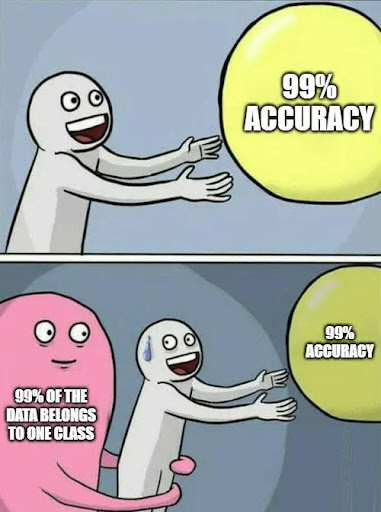

source: *Data Science Dojo - https://datasciencedojo.com/blog/data-science-memes/*

</details>

## Text classification

In [22]:
# Keep relevant columns for text classification
trans_df = df_a[['cdt', 'dot', 'tcode']]
trans_df.head()

,cdt,dot,tcode
0,not provided,DIAMONDS,1101
1,289,DIAMONDS,1101
2,see payment advice note from 23 01,DIAMONDS,1101
3,see payment advice note from 31 01,DIAMONDS,1101
4,not provided,DIAMONDS,1101


### Text handling

Tokenize

In [23]:
#nltk.download('punkt')
#nltk.download('punkt_tab')

# Tokenize the 'cdt' column and store in a new column
trans_df.loc[:, 'tokenized_cdt'] = trans_df['cdt'].apply(nltk.word_tokenize)
display(trans_df.head(5))

/tmp/ipython-input-2527002325.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trans_df.loc[:, 'tokenized_cdt'] = trans_df['cdt'].apply(nltk.word_tokenize)


,cdt,dot,tcode,tokenized_cdt
0,not provided,DIAMONDS,1101,"[not, provided]"
1,289,DIAMONDS,1101,[289]
2,see payment advice note from 23 01,DIAMONDS,1101,"[see, payment, advice, note, from, 23, 01]"
3,see payment advice note from 31 01,DIAMONDS,1101,"[see, payment, advice, note, from, 31, 01]"
4,not provided,DIAMONDS,1101,"[not, provided]"


Remove non-word characters like semicolon, commas, etc.

In [24]:
# Remove non-word characters from each tokenized sentence
trans_df.loc[:, 'cleaned_tokenized_cdt'] = trans_df['tokenized_cdt'].apply(lambda tokens: [word for word in tokens if word.isalpha()])

display(trans_df.head(5))

/tmp/ipython-input-801016573.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trans_df.loc[:, 'cleaned_tokenized_cdt'] = trans_df['tokenized_cdt'].apply(lambda tokens: [word for word in tokens if word.isalpha()])


,cdt,dot,tcode,tokenized_cdt,cleaned_tokenized_cdt
0,not provided,DIAMONDS,1101,"[not, provided]","[not, provided]"
1,289,DIAMONDS,1101,[289],[]
2,see payment advice note from 23 01,DIAMONDS,1101,"[see, payment, advice, note, from, 23, 01]","[see, payment, advice, note, from]"
3,see payment advice note from 31 01,DIAMONDS,1101,"[see, payment, advice, note, from, 31, 01]","[see, payment, advice, note, from]"
4,not provided,DIAMONDS,1101,"[not, provided]","[not, provided]"


Remove stopwords

In [25]:
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get the list of English stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords from each cleaned tokenized sentence
trans_df.loc[:, 'filtered_cdt'] = trans_df['cleaned_tokenized_cdt'].apply(lambda tokens: [word for word in tokens if word.lower() not in stop_words])

display(trans_df.head(5))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/tmp/ipython-input-780218825.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trans_df.loc[:, 'filtered_cdt'] = trans_df['cleaned_tokenized_cdt'].apply(lambda tokens: [word for word in tokens if word.lower() not in stop_words])


,cdt,dot,tcode,tokenized_cdt,cleaned_tokenized_cdt,filtered_cdt
0,not provided,DIAMONDS,1101,"[not, provided]","[not, provided]",[provided]
1,289,DIAMONDS,1101,[289],[],[]
2,see payment advice note from 23 01,DIAMONDS,1101,"[see, payment, advice, note, from, 23, 01]","[see, payment, advice, note, from]","[see, payment, advice, note]"
3,see payment advice note from 31 01,DIAMONDS,1101,"[see, payment, advice, note, from, 31, 01]","[see, payment, advice, note, from]","[see, payment, advice, note]"
4,not provided,DIAMONDS,1101,"[not, provided]","[not, provided]",[provided]


Lower case (if needed)

In [26]:
# Convert all words to lowercase
trans_df.loc[:, 'lowercase_cdt'] = trans_df['filtered_cdt'].apply(lambda tokens: [word.lower() for word in tokens])

display(trans_df.head(5))

/tmp/ipython-input-1850497463.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trans_df.loc[:, 'lowercase_cdt'] = trans_df['filtered_cdt'].apply(lambda tokens: [word.lower() for word in tokens])


,cdt,dot,tcode,tokenized_cdt,cleaned_tokenized_cdt,filtered_cdt,lowercase_cdt
0,not provided,DIAMONDS,1101,"[not, provided]","[not, provided]",[provided],[provided]
1,289,DIAMONDS,1101,[289],[],[],[]
2,see payment advice note from 23 01,DIAMONDS,1101,"[see, payment, advice, note, from, 23, 01]","[see, payment, advice, note, from]","[see, payment, advice, note]","[see, payment, advice, note]"
3,see payment advice note from 31 01,DIAMONDS,1101,"[see, payment, advice, note, from, 31, 01]","[see, payment, advice, note, from]","[see, payment, advice, note]","[see, payment, advice, note]"
4,not provided,DIAMONDS,1101,"[not, provided]","[not, provided]",[provided],[provided]


Stemming

In [27]:
from nltk.stem import PorterStemmer

# create an object of class PorterStemmer
porter = PorterStemmer()

# Stem each word in each filtered sentence
trans_df.loc[:, 'stemmed_cdt'] = trans_df['filtered_cdt'].apply(lambda tokens: [porter.stem(word) for word in tokens])

display(trans_df.head(5))

/tmp/ipython-input-1864496034.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trans_df.loc[:, 'stemmed_cdt'] = trans_df['filtered_cdt'].apply(lambda tokens: [porter.stem(word) for word in tokens])


,cdt,dot,tcode,tokenized_cdt,cleaned_tokenized_cdt,filtered_cdt,lowercase_cdt,stemmed_cdt
0,not provided,DIAMONDS,1101,"[not, provided]","[not, provided]",[provided],[provided],[provid]
1,289,DIAMONDS,1101,[289],[],[],[],[]
2,see payment advice note from 23 01,DIAMONDS,1101,"[see, payment, advice, note, from, 23, 01]","[see, payment, advice, note, from]","[see, payment, advice, note]","[see, payment, advice, note]","[see, payment, advic, note]"
3,see payment advice note from 31 01,DIAMONDS,1101,"[see, payment, advice, note, from, 31, 01]","[see, payment, advice, note, from]","[see, payment, advice, note]","[see, payment, advice, note]","[see, payment, advic, note]"
4,not provided,DIAMONDS,1101,"[not, provided]","[not, provided]",[provided],[provided],[provid]


Convert columns to string

In [28]:
for col in trans_df.columns:
    if 'cdt' in col:
        trans_df.loc[:, col] = trans_df[col].astype(str).str.strip('[]')

In [29]:
display(trans_df.head(5))
display(trans_df.tail(5))

,cdt,dot,tcode,tokenized_cdt,cleaned_tokenized_cdt,filtered_cdt,lowercase_cdt,stemmed_cdt
0,not provided,DIAMONDS,1101,"'not', 'provided'","'not', 'provided'",'provided','provided','provid'
1,289,DIAMONDS,1101,'289',,,,
2,see payment advice note from 23 01,DIAMONDS,1101,"'see', 'payment', 'advice', 'note', 'from', '2...","'see', 'payment', 'advice', 'note', 'from'","'see', 'payment', 'advice', 'note'","'see', 'payment', 'advice', 'note'","'see', 'payment', 'advic', 'note'"
3,see payment advice note from 31 01,DIAMONDS,1101,"'see', 'payment', 'advice', 'note', 'from', '3...","'see', 'payment', 'advice', 'note', 'from'","'see', 'payment', 'advice', 'note'","'see', 'payment', 'advice', 'note'","'see', 'payment', 'advic', 'note'"
4,not provided,DIAMONDS,1101,"'not', 'provided'","'not', 'provided'",'provided','provided','provid'


,cdt,dot,tcode,tokenized_cdt,cleaned_tokenized_cdt,filtered_cdt,lowercase_cdt,stemmed_cdt
8459,sars 2025,REDUCTION IN DEPOSITS IN MyCountry - NON-FINAN...,1859,"'sars', '2025'",'sars','sars','sars','sar'
8460,school fees,REDUCTION IN DEPOSITS IN MyCountry - NON-FINAN...,1859,"'school', 'fees'","'school', 'fees'","'school', 'fees'","'school', 'fees'","'school', 'fee'"
8461,bwt interco settlement oct 24,FOREIGN ACCOUNTS REPLENISHMENT,1913,"'bwt', 'interco', 'settlement', 'oct', '24'","'bwt', 'interco', 'settlement', 'oct'","'bwt', 'interco', 'settlement', 'oct'","'bwt', 'interco', 'settlement', 'oct'","'bwt', 'interco', 'settlement', 'oct'"
8462,b2024/12,FOREIGN ACCOUNTS REPLENISHMENT,1913,'b2024/12',,,,
8463,gwp unspent funds,FOREIGN ACCOUNTS REPLENISHMENT,1913,"'gwp', 'unspent', 'funds'","'gwp', 'unspent', 'funds'","'gwp', 'unspent', 'funds'","'gwp', 'unspent', 'funds'","'gwp', 'unspent', 'fund'"


<br>
<h3> <b>❓ Which of the above columns would you use to train a classification model?
</b>

Let's try with stemmed_cdt column but first removing blank rows or those that did not provide description

In [30]:
# Remove rows where 'stemmed_cdt' is blank or 'provid'
trans_df_filtered = trans_df[(trans_df['stemmed_cdt'] != '') & (trans_df['stemmed_cdt'] != "'provid'")]

# Display the shape of the original and filtered DataFrames
print(f"Original DataFrame shape: {trans_df.shape}")
print(f"Filtered DataFrame shape: {trans_df_filtered.shape}")

# Display the first few rows of the filtered DataFrame
display(trans_df_filtered.head())

Original DataFrame shape: (8464, 8)
Filtered DataFrame shape: (6813, 8)


,cdt,dot,tcode,tokenized_cdt,cleaned_tokenized_cdt,filtered_cdt,lowercase_cdt,stemmed_cdt
2,see payment advice note from 23 01,DIAMONDS,1101,"'see', 'payment', 'advice', 'note', 'from', '2...","'see', 'payment', 'advice', 'note', 'from'","'see', 'payment', 'advice', 'note'","'see', 'payment', 'advice', 'note'","'see', 'payment', 'advic', 'note'"
3,see payment advice note from 31 01,DIAMONDS,1101,"'see', 'payment', 'advice', 'note', 'from', '3...","'see', 'payment', 'advice', 'note', 'from'","'see', 'payment', 'advice', 'note'","'see', 'payment', 'advice', 'note'","'see', 'payment', 'advic', 'note'"
25,goods- diamonds dr,DIAMONDS,1101,"'goods-', 'diamonds', 'dr'","'diamonds', 'dr'","'diamonds', 'dr'","'diamonds', 'dr'","'diamond', 'dr'"
26,"goods- copper, nickel dr",COPPER AND NICKEL,1103,"'goods-', 'copper', ',', 'nickel', 'dr'","'copper', 'nickel', 'dr'","'copper', 'nickel', 'dr'","'copper', 'nickel', 'dr'","'copper', 'nickel', 'dr'"
28,merchandise imports,TEXTILES,1106,"'merchandise', 'imports'","'merchandise', 'imports'","'merchandise', 'imports'","'merchandise', 'imports'","'merchandis', 'import'"


This is the input Data Frame for the models

In [31]:
X_var = 'stemmed_cdt' # Try to run the model using a different input
input_df = trans_df_filtered[[X_var, 'tcode']]
input_df = input_df.rename(columns={X_var: 'X', 'tcode': 'y'})
display(input_df.head())

,X,y
2,"'see', 'payment', 'advic', 'note'",1101
3,"'see', 'payment', 'advic', 'note'",1101
25,"'diamond', 'dr'",1101
26,"'copper', 'nickel', 'dr'",1103
28,"'merchandis', 'import'",1106


**Recap prior to training our first model**

From the documentation for *sklearn.feature_extraction.text*:

> "Text Analysis is a major application field for machine learning algorithms. However the raw data, a sequence of symbols **cannot be fed directly to the algorithms** themselves as most of them expect numerical feature vectors with a fixed size rather than the raw text documents with variable length.

> In order to address this, scikit-learn provides utilities for the most common ways to extract numerical features from text content, namely:

> - **tokenizing** strings and giving an integer id for each possible token, for instance by using white-spaces and punctuation as token separators.

> - **counting** the occurrences of tokens in each document.

> - **normalizing** and **weighting** with diminishing importance tokens that occur in the majority of samples / documents."

source: https://scikit-learn.org/1.6/modules/feature_extraction.html#text-feature-extraction


### Train a Random Forest model with TF-IDF

☝ **What is TF-IDF?** (Term Frequency–Inverse Document Frequency)

- TF-IDF is a technique used to convert text into numerical features that can be used in machine learning models. It helps identify which words are important in a document relative to a collection (corpus) of documents.

  It has two components:

  1. **Term Frequency (TF)**:

    How often a word appears in a category.

    The more it appears, the more "important" it might be for that category.

  2. **Inverse Document Frequency (IDF**):

    Downweights words that appear in many categories (like "the", "is", etc.), because they’re not informative.

    Rare words get higher scores.

  <br>
    👉 TF-IDF helps find important, unique words for each category. It also builds a sparse matrix of terms.

☝ **How does Random Forests work?**
http://www.r2d3.us/visual-intro-to-machine-learning-part-1/

1. First, the text data needs to be converted into a numerical format that the algorithm can understand. Like TF-IDF.

2. Once the text is vectorized, a Random Forest builds an ensemble of decision trees. Each individual decision tree is trained on a random subset of the training data (bootstrapping) and considers only a random subset of the features (words/terms) at each split point.

3. This randomness helps to reduce overfitting and the correlation between individual trees. For text data, a decision tree might make splits based on the presence or absence of certain important words, or the TF-IDF score of particular terms.

4. To classify a new text document, the vectorized representation of the document is passed down each of the decision trees in the forest. Each tree independently predicts a class label. The Random Forest then combines these individual predictions, typically by taking a majority vote among all the trees, to arrive at the final classification for the text.

5. This ensemble approach leverages the diversity of the individual trees to produce a more robust and accurate classification than a single decision tree would achieve on its own.



Note: We remove classes with <= 3 members. Why?

In train_test_split , the **stratify parameter** ensures that the training and testing sets have the same proportion of classes (or labels) as the original dataset. This is particularly useful when dealing with imbalanced datasets, where some classes are underrepresented. https://medium.com/@aymuosmukherjee/why-do-we-use-stratify-in-train-test-split-e3eb296a5494

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

# Define features (X) and target (y)
X = input_df['X']
y = input_df['y']

# Get the counts of each class
class_counts = y.value_counts()

# Identify classes with 3 or fewer members
rare_classes = class_counts[class_counts <= 3].index

# Filter the DataFrame to exclude rows with rare classes
input_df_filtered = input_df[~input_df['y'].isin(rare_classes)].copy()

# Update features (X) and target (y) with the filtered data
X = input_df_filtered['X']
y = input_df_filtered['y']


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the test data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


### Evaluate the model

<h4> Standard Machine Learning Metrics </h4>



1. **Accuracy**: The proportion of correctly classified instances out of the total instances.  
   Formula:  
   $$ \text{Accuracy} = \frac{\text{True Positives} + \text{True Negatives}}{\text{Total Instances}} $$

2. **Precision**: The proportion of true positive predictions among all positive predictions made. It answers how many of the predicted positives were actually correct.  
   Formula:  
   $$ \text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}} $$

3. **Recall** (Sensitivity): The proportion of actual positives that were correctly identified. It answers how many of the actual positives were correctly predicted.  
   Formula:  
   $$ \text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}} $$

4. **F1-Score**: The harmonic mean of precision and recall, providing a balance between the two metrics. It is useful when you need a balance between precision and recall.  
   Formula:  
   $$ \text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$

5. **Support**: The number of actual occurrences of the class in the dataset. It helps to understand the distribution of classes and provides context for the other metrics.


In [33]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter

# Predict on the test data
y_pred = rf_model.predict(X_test_tfidf)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Print overall metrics
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")
print(f"Weighted F1 Score: {weighted_f1:.4f}")

Classification Report:
              precision    recall  f1-score   support

        1106       0.89      0.24      0.38        33
        1107       0.84      0.56      0.68        85
        1110       0.87      0.47      0.61        99
        1111       0.85      0.68      0.75        34
        1112       0.36      0.29      0.32        31
        1113       0.67      0.91      0.77       634
        1202       0.40      0.67      0.50         3
        1203       1.00      0.67      0.80         3
        1205       0.00      0.00      0.00         2
        1206       0.00      0.00      0.00         3
        1209       0.57      0.42      0.48        19
        1221       0.00      0.00      0.00         1
        1222       0.67      1.00      0.80         2
        1223       0.56      0.31      0.40        16
        1224       0.64      0.39      0.48        18
        1240       0.00      0.00      0.00         1
        1246       0.00      0.00      0.00         2
    

Now use the pre-defined function for a more detailed report

In [34]:
# First create a dictionary to map codes to labels
label_to_code = dict(df_a[['dot', 'tcode']].dropna().drop_duplicates().values)

In [35]:
# Display the first 10 items in the dictionary
for i, (key, value) in enumerate(list(label_to_code.items())[:10]):
    print(f"{key}: {value}")

DIAMONDS: 1101
COPPER AND NICKEL: 1103
MEAT AND MEAT PRODUCTS: 1104
TEXTILES: 1106
VEHICLES: 1107
LIVE ANIMALS: 1108
FOOD: 1110
FUEL: 1111
MACHINERY: 1112
OTHER GOODS: 1113


Run using predefined helper function. Should get same results

In [36]:
# Initialize and train the Random Forest model
rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42)

results_rf = train_evaluate_model(rf_model2, X_train_tfidf, X_test_tfidf, y_train, y_test,top_n = 30, label="RandomForestClassifier - TFIDF", full_report=False)


🔍 Evaluating Model: RandomForestClassifier - TFIDF

📊 Classification Report (Summary):

📈 Accuracy: 0.68
Macro F1 Score: 0.38
Weighted F1 Score: 0.65

❌ Underperforming Classes (F1 < 0.3):
  - 1252: F1 = 0.08
  - 1249: F1 = 0.11
  - 1417: F1 = 0.18
  - 1265: F1 = 0.22
  - 1262: F1 = 0.29

✅ Well-performing Classes (F1 ≥ 0.7):
  - 1301: F1 = 0.88
  - 1843: F1 = 0.83
  - 1113: F1 = 0.77
  - 1111: F1 = 0.75


### Model improvements

Try with a different feature extraction:

- filter out entries with fewer than x number of words
- SMOTE
- Class grouping


Option 1: Remove majority class. Since the '*Other Goods*' category appears in more than 40% of records.

In [37]:
####Exclude the 'Other Goods' category as it could give us misguided results

# Create the feature matrix
input_df_NOG = input_df[input_df['y'] != 1113].copy()

input_df_NOG = input_df_NOG.reset_index(drop=True)
input_df_NOG.shape

(3644, 2)

Check we now have 1 less category

In [38]:
print(f"Unique categories in the full dataset: {len(input_df.y.unique())} \nUnique categories in the filtered dataframe {len(input_df_NOG.y.unique())}")

Unique categories in the full dataset: 104 
Unique categories in the filtered dataframe 103


Repeat steps to train the RF model with input_df_NOG this time

In [39]:
# Define features (X) and target (y)
X = input_df_NOG['X']
y = input_df_NOG['y']

# Get the counts of each class
class_counts = y.value_counts()

# Identify classes with 3 or fewer members
rare_classes = class_counts[class_counts <= 3].index

# Filter the DataFrame to exclude rows with rare classes
input_df_NOG_filtered = input_df_NOG[~input_df_NOG['y'].isin(rare_classes)].copy()

# Update features (X) and target (y) with the filtered data
X = input_df_NOG_filtered['X']
y = input_df_NOG_filtered['y']


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the test data
X_test_tfidf = tfidf_vectorizer.transform(X_test)


# Initialize and train the Random Forest model
rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42)

results_rf = train_evaluate_model(rf_model2, X_train_tfidf, X_test_tfidf, y_train, y_test,top_n = 30, label="RandomForestClassifier - TFIDF", full_report=False)


🔍 Evaluating Model: RandomForestClassifier - TFIDF

📊 Classification Report (Summary):

📈 Accuracy: 0.61
Macro F1 Score: 0.39
Weighted F1 Score: 0.62

❌ Underperforming Classes (F1 < 0.3):
  - 1419: F1 = 0.16
  - 1417: F1 = 0.22
  - 1262: F1 = 0.25
  - 1812: F1 = 0.25

✅ Well-performing Classes (F1 ≥ 0.7):
  - 1301: F1 = 0.87
  - 1612: F1 = 0.79
  - 1107: F1 = 0.76
  - 1110: F1 = 0.74
  - 1843: F1 = 0.73
  - 1224: F1 = 0.72


Compare results with previous model

Option 2: SMOTE

So far, we have removed classes that were either under or over represented.

As an alternative, we could try to correct the class imbalance. SMOTE creates synthetic examples of underrepresented classes by interpolating between nearby minority samples — helping your classifier learn better without overfitting to duplicated data.

In [40]:
from collections import Counter
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


# Define features (X) and target (y)
X = input_df['X']
y = input_df['y']

# Identify classes with 3 or fewer members
class_counts = y.value_counts()
rare_classes = class_counts[class_counts <= 3].index

# Filter the DataFrame to exclude rows with rare classes
input_df_filtered = input_df[~input_df['y'].isin(rare_classes)].copy()

# Update features (X) and target (y) with the filtered data
X = input_df_filtered['X']
y = input_df_filtered['y']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the test data
X_test_tfidf = tfidf_vectorizer.transform(X_test)


# Step 1: Inspect current class counts
class_counts = Counter(y_train)

# Thresholds
MAX_SAMPLES = 500         # Upper cap per class (e.g., to reduce 'Other Goods')
RARE_THRESHOLD = 2        # Classes with ≤ this use ROS
SMOTE_MIN_THRESHOLD = 3   # Classes with ≥ this can use SMOTE
TARGET_SAMPLES = 30       # Target size for rare classes

# 1. Under-sampling strategy (for dominant classes like 'Other Goods')
under_strategy = {
    cls: min(count, MAX_SAMPLES)
    for cls, count in class_counts.items()
}

# 2. Over-sampling strategy (for rare classes)
ros_strategy = {}
smote_strategy = {}

for cls, count in class_counts.items():
    if count <= RARE_THRESHOLD:
        ros_strategy[cls] = min(5, TARGET_SAMPLES)
    elif RARE_THRESHOLD < count < TARGET_SAMPLES:
        smote_strategy[cls] = TARGET_SAMPLES

# 3. Build combined pipeline
rus = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
ros = RandomOverSampler(sampling_strategy=ros_strategy, random_state=42)
smote = SMOTE(sampling_strategy=smote_strategy, random_state=42, k_neighbors=2)

resample_pipeline = Pipeline([
    ('under', rus),
    ('ros', ros),
    ('smote', smote)
])

# 4. Apply it to your training data
X_train_res, y_train_res = resample_pipeline.fit_resample(X_train_tfidf, y_train)

# 5. Check result
print("✅ Final Class Distribution:")
print(Counter(y_train_res))

✅ Final Class Distribution:
Counter({1113: 500, 1110: 396, 1301: 378, 1107: 341, 1407: 197, 1855: 160, 1111: 138, 1106: 133, 1112: 124, 1249: 105, 1302: 82, 1209: 76, 1224: 71, 1223: 66, 1612: 60, 1252: 51, 1419: 46, 1202: 30, 1203: 30, 1205: 30, 1206: 30, 1221: 30, 1222: 30, 1240: 30, 1246: 30, 1248: 30, 1250: 30, 1253: 30, 1255: 30, 1256: 30, 1257: 30, 1258: 30, 1259: 30, 1261: 30, 1262: 30, 1264: 30, 1265: 30, 1268: 30, 1271: 30, 1273: 30, 1278: 30, 1284: 30, 1286: 30, 1408: 30, 1410: 30, 1411: 30, 1416: 30, 1417: 30, 1424: 30, 1611: 30, 1613: 30, 1614: 30, 1623: 30, 1717: 30, 1722: 30, 1811: 30, 1812: 30, 1831: 30, 1843: 30, 1851: 30, 1859: 30})


In [41]:
# Initialize and train the Random Forest model
rf_model_resampled = RandomForestClassifier(n_estimators=100, random_state=42)

# Evaluate the model with the re-sampled training data and original test data
results_rf_resampled = train_evaluate_model(rf_model_resampled, X_train_res, X_test_tfidf, y_train_res, y_test,top_n = 30, label="RandomForestClassifier - TFIDF (SMOTE)", full_report=False)


🔍 Evaluating Model: RandomForestClassifier - TFIDF (SMOTE)

📊 Classification Report (Summary):

📈 Accuracy: 0.63
Macro F1 Score: 0.37
Weighted F1 Score: 0.63

❌ Underperforming Classes (F1 < 0.3):
  - 1252: F1 = 0.07
  - 1249: F1 = 0.13
  - 1265: F1 = 0.18
  - 1417: F1 = 0.20
  - 1262: F1 = 0.29

✅ Well-performing Classes (F1 ≥ 0.7):
  - 1301: F1 = 0.86
  - 1843: F1 = 0.83
  - 1113: F1 = 0.72
  - 1107: F1 = 0.71


Feature engineering is almost always a good idea. For instance we could add dummy variables for the country of destination, or other non-text input data, like monetary value of transactions, etc.

<h3> <b>❓ What other strategies could we follow to improve results?
</b>

## Advanced: FastText classification

FastText for classification: https://fasttext.cc/docs/en/supervised-tutorial.html

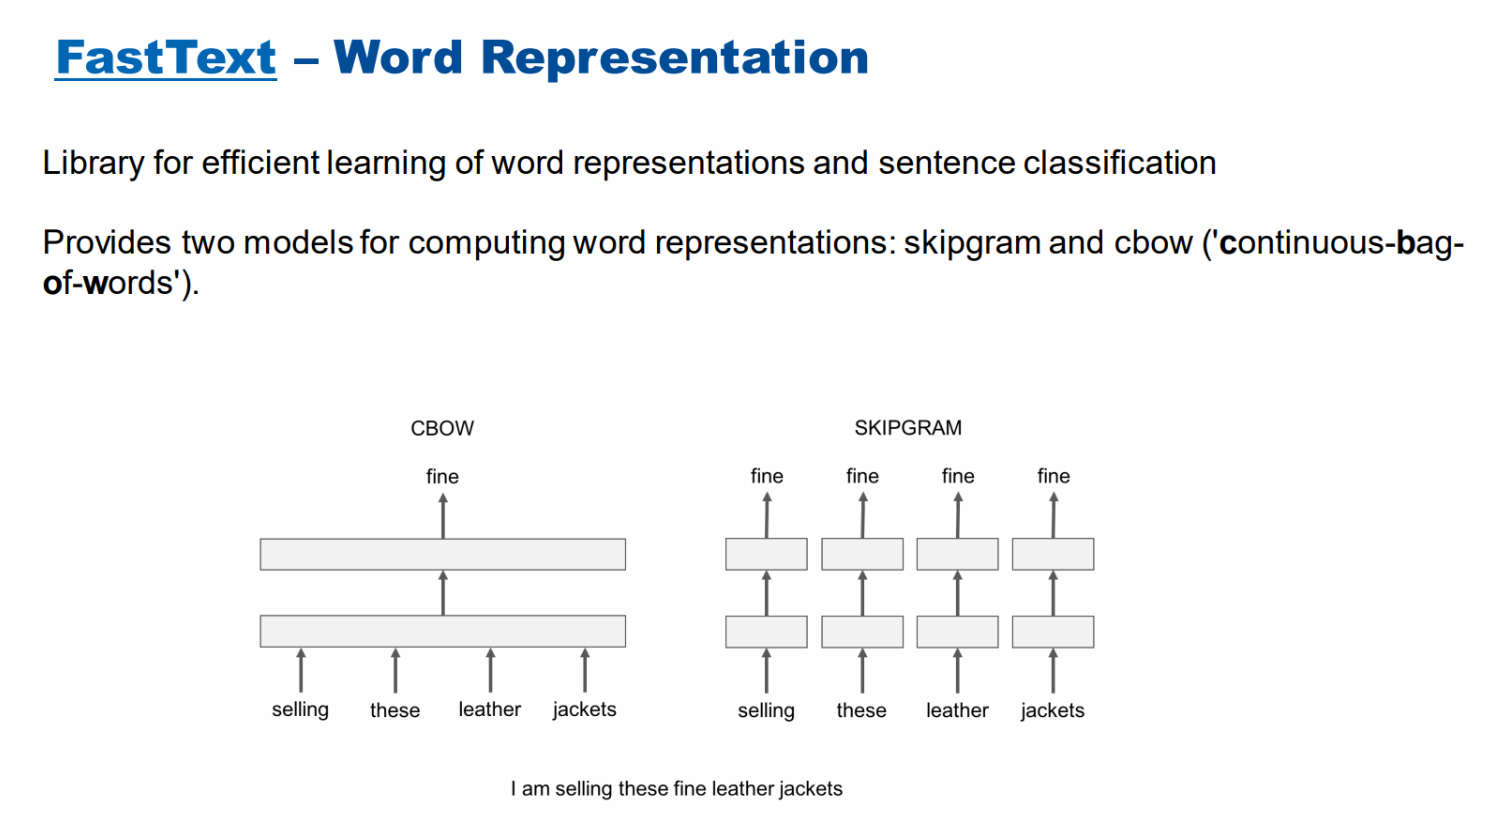

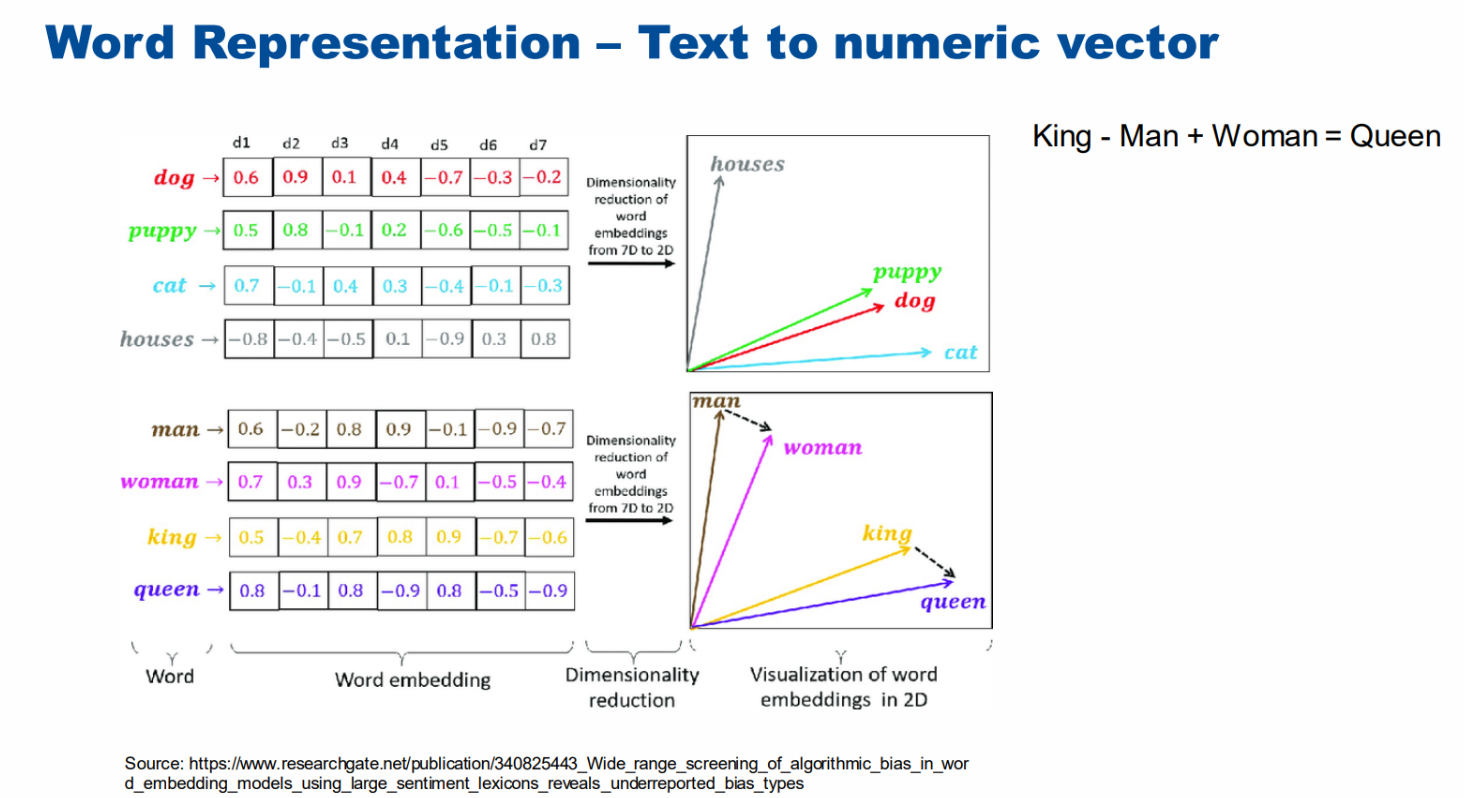

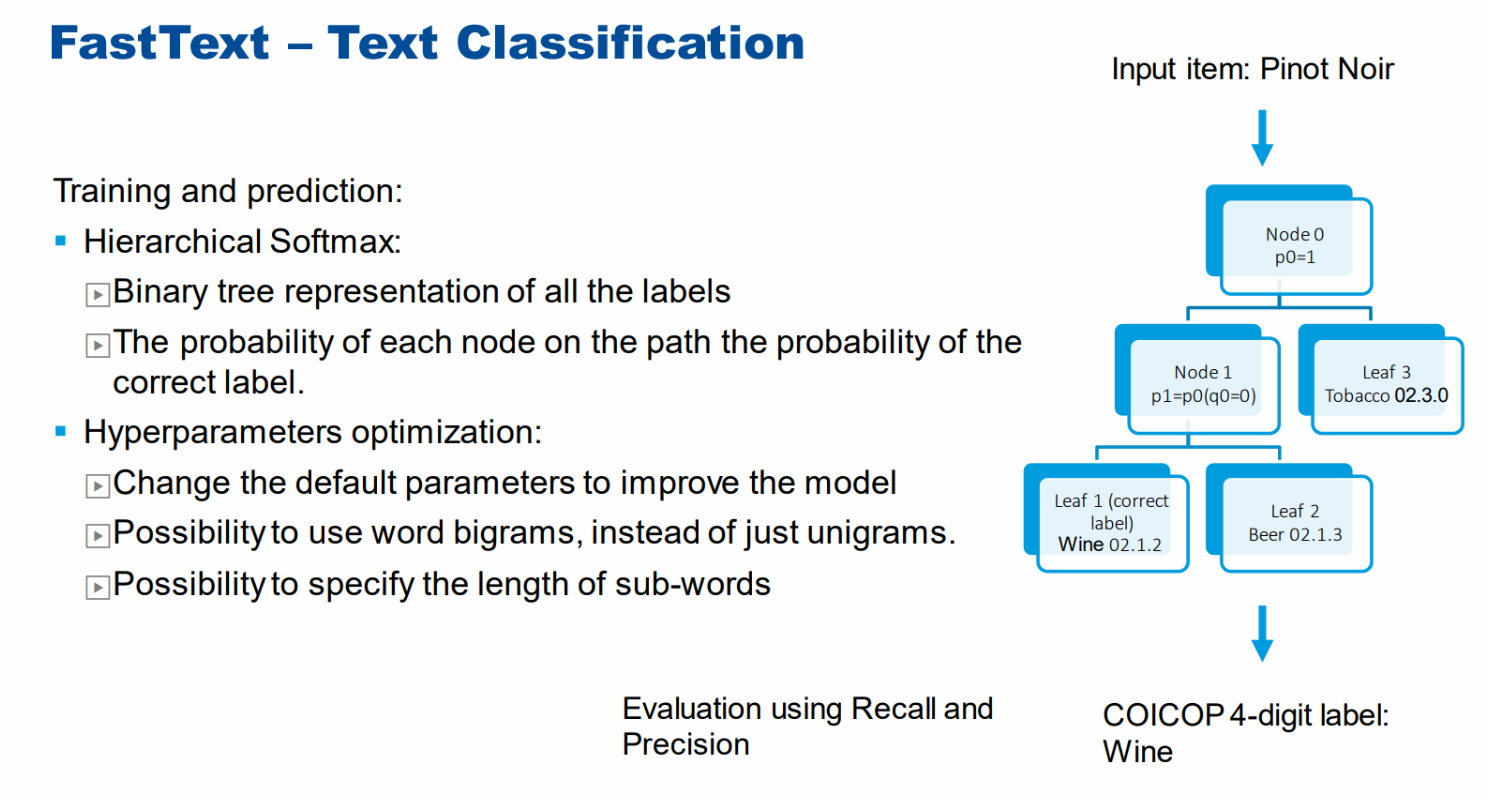

### Preparing the data

In [42]:
!pip install fasttext-numpy2 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 kB 18.7 MB/s eta 0:00:00


Use the original descriptions for the transactions

In [43]:
prep_fast_df = df_a[['cdt', 'tcode']].copy()
prep_fast_df = prep_fast_df.rename(columns={'cdt': 'X', 'tcode': 'y'})
display(prep_fast_df.head())

,X,y
0,not provided,1101
1,289,1101
2,see payment advice note from 23 01,1101
3,see payment advice note from 31 01,1101
4,not provided,1101


In [44]:
#Apply the sanitize_text_simple function to the 'cdt' column and assign it to X_test
prep_fast_df['X'] = prep_fast_df['X'].apply(lambda x: sanitize_text_simple(x))
display(prep_fast_df.head())

,X,y
0,not provided,1101
1,,1101
2,see payment advice note from,1101
3,see payment advice note from,1101
4,not provided,1101


In [45]:
# Remove not provided, empty, and 'nan' string transactions
prep_fast_df = prep_fast_df[(prep_fast_df['X'] != 'not provided') & (prep_fast_df['X'] != '') & (prep_fast_df['X'] != 'nan')]

In [46]:
# Convert df into the format required for fasttext
fast_df = prep_fast_df.copy()
fast_df.y = ["__label__" + str(fast_df.y.loc[j]) for j in fast_df.y.index]

#input_df = input_df.drop("id", axis=1)
print(fast_df.shape)
display(fast_df.head())

(7408, 2)


,X,y
2,see payment advice note from,__label__1101
3,see payment advice note from,__label__1101
25,goods diamonds dr,__label__1101
26,goods copper nickel dr,__label__1103
27,zmtinvs,__label__1104


In [47]:
from sklearn.model_selection import train_test_split

# Split fast_df into 2 data frames (80% train, 20% test) randomly
fast_train_df, fast_test_df = train_test_split(fast_df, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"Training set shape: {fast_train_df.shape}")
print(f"Testing set shape: {fast_test_df.shape}")

Data split into training and testing sets.
Training set shape: (5926, 2)
Testing set shape: (1482, 2)


In [51]:
# Check data types in the 'X' column of fast_train_df
print("Data types in fast_train_df['X']:")
print(fast_train_df['X'].apply(type).value_counts())

# Check for any non-string values in the 'X' column
non_string_x = fast_train_df[~fast_train_df['X'].apply(lambda x: isinstance(x, str))]
print("\nRows with non-string values in fast_train_df['X']:")
display(non_string_x)

# Further inspect potentially problematic string values (e.g., empty strings or strings that might convert to NaN)
# This is a heuristic check and might need adjustment based on the actual data
problematic_strings_x = fast_train_df[fast_train_df['X'].apply(lambda x: isinstance(x, str) and (x.strip() == '' or x.lower() == 'nan'))]
print("\nRows with empty or 'nan' string values in fast_train_df['X']:")
display(problematic_strings_x)

Data types in fast_train_df['X']:
X
<class 'str'>    5926
Name: count, dtype: int64

Rows with non-string values in fast_train_df['X']:


,X,y



Rows with empty or 'nan' string values in fast_train_df['X']:


,X,y


In [52]:
import tempfile
import os

# Save the training DataFrame to a temporary file
with tempfile.NamedTemporaryFile(mode='w', delete=False, encoding='utf-8') as f_train:
    for index, row in fast_train_df.iterrows():
        f_train.write(f"{row['y']} {str(row['X'])}\n")
    train_file_path = f_train.name

# Verify the file format
print(f"Temporary file created at: {train_file_path}")
print("\nFirst 5 lines of the temporary file:")
with open(train_file_path, 'r', encoding='utf-8') as f:
    for i in range(5):
        line = f.readline()
        if line:
            print(line.strip())
        else:
            break
print("-" * 20)

# Save the testing DataFrame to a temporary file
with tempfile.NamedTemporaryFile(mode='w', delete=False, encoding='utf-8') as f_test:
    for index, row in fast_test_df.iterrows():
        f_test.write(f"{row['y']} {str(row['X'])}\n")
    test_file_path = f_test.name

# Verify the file format
print(f"Temporary file created at: {test_file_path}")
print("\nFirst 5 lines of the temporary file:")
with open(test_file_path, 'r', encoding='utf-8') as f:
    for i in range(5):
        line = f.readline()
        if line:
            print(line.strip())
        else:
            break
print("-" * 20)

print(f"Training data saved to: {train_file_path}")
print(f"Testing data saved to: {test_file_path}")

Temporary file created at: /tmp/tmpsfak94a_

First 5 lines of the temporary file:
__label__1110 senn foods logistics pty ltd
__label__1107 vehicle purchase
__label__1266 pwc mycountry so
__label__1111 product payment december
__label__1107 car purchase
--------------------
Temporary file created at: /tmp/tmpcfkq6nz9

First 5 lines of the temporary file:
__label__1113 j haskins
__label__1110 masterfarmerfeeds
__label__1248 risk database july dec
__label__1113 goods other goods dr
__label__1113 smbw pays smas
--------------------
Training data saved to: /tmp/tmpsfak94a_
Testing data saved to: /tmp/tmpcfkq6nz9


### Train the model

In [53]:
import fasttext

# Train the FastText model using the training file
model_ft = fasttext.train_supervised(input=train_file_path)

print("FastText model trained successfully!")

# You can now evaluate the model using the test_file_path

FastText model trained successfully!


Test the model: Try with different inputs!

In [73]:
prediction = model_ft.predict("salaries") # try different inputs
print(prediction)
# Filter prep_fast_df by a specific value in the 'y' column in one line
pred_value = int(str(prediction[0][0]).replace('__label__', ''))

# Sample entries with same label from input data frame
print('\n Sample entries with same label from input data frame')
sample_input_ft = prep_fast_df[prep_fast_df['y'] == pred_value]
display(sample_input_ft.head())

print('\n Correct label')
df_codes_1[df_codes_1['CODE'] == pred_value]

(('__label__1301',), array([0.89395994]))

 Sample entries with same label from input data frame


,X,y
6691,timothy roddy,1301
6692,mhs fees,1301
6693,mr mbiasah lionel,1301
6694,zou dehong,1301
6695,adven mycountry construction,1301



 Correct label


,PURPOSE,CODE
82,"SALARIES, WAGES, ALLOWANCES AND DIRECTORS' FEES",1301


Look at the quality of results:

(Sample size, precision, recall)

In [57]:
model_ft.test(test_file_path)

(1477, 0.5815842924847664, 0.5815842924847664)

The precision is the number of correct labels among the labels predicted by fastText. The recall is the number of labels that successfully were predicted, among all the real labels. If we include the top 5 predicted for each entry, precision and recall will change:

In [58]:
model_ft.test(test_file_path, k = 5) # look at the top 5 classes predicted (probabilities)

(1477, 0.15287745429925526, 0.7643872714962763)

Precision did not get worse, simply, we are now considering 5 options instead of the top 1 result, thus, if one out of five labels predicted by the model is correct, it gives a precision of 0.20. Averaging them over the whole test dataset, gives the precision in this case.  

Let's look at one single example to illustrate this better

SORT BY PROBABILITY

In [70]:
prediction = model_ft.predict("toyota", k = 5) # try different inputs
print('\n Top 5 predicted')
display(prediction)

pred_value = int(str(prediction[0][0]).replace('__label__', ''))
top_5_pred = [int(str(pred).replace('__label__', '')) for pred in list(prediction[0])]

print('\n Correct label')
df_codes_1[df_codes_1['CODE'].isin(top_5_pred)]
for pred in top_5_pred:
  print(df_codes_1[df_codes_1['CODE'] == pred].iloc[0].PURPOSE)


 Top 5 predicted


(('__label__1113',
  '__label__1107',
  '__label__1855',
  '__label__1111',
  '__label__1249'),
 array([0.39538676, 0.23687072, 0.05992666, 0.04208609, 0.03769548]))


 Correct label
OTHER GOODS
VEHICLES
DEPOSITS ABROAD-NON-BANK FINANCIAL INSTITUTIONS, OTHER COMPANIES, INDIVIDUALS
FUEL
COMPUTER SERVICES


If the correct label is among the top 5 returned, then precision is 0.20.

Try with different number of returned results and input words!

**Prettify outputs: Test this**

In [ ]:
print("top 1 results")

def print_results(N, p, r):
    print("N\t" + str(N))
    print("Precision@{}\t{:.3f}".format(1, p))
    print("Recall@{}\t{:.3f}".format(1, r))

print_results(*model_ft2.test(test_file_path))

### Scaling things up

Tune parameters to improve results:

- changing the number of epochs (using the option -epoch, standard range [5 - 50])

- changing the learning rate (using the option -lr, standard range [0.1 - 1.0])

- using word n-grams (using the option -wordNgrams, standard range [1 - 5]).

In [71]:
# Train the FastText model using the training file
model_ft2 = fasttext.train_supervised(input=train_file_path, lr=1.0, epoch=25, wordNgrams=2)

print("FastText model trained successfully!")

FastText model trained successfully!


Test the new model

In [75]:
prediction = model_ft2.predict("dividends") # try different inputs
print(prediction)
# Filter prep_fast_df by a specific value in the 'y' column in one line
pred_value = int(str(prediction[0][0]).replace('__label__', ''))

# Sample entries with same label from input data frame
print('\n Sample entries with same label from input data frame')
sample_input_ft = prep_fast_df[prep_fast_df['y'] == pred_value]
display(sample_input_ft.head())

print('\n Correct label')
df_codes_1[df_codes_1['CODE'] == pred_value]

(('__label__1302',), array([0.99775928]))

 Sample entries with same label from input data frame


,X,y
7241,escrow agreement,1302
7242,family maintenance workers remittances dr,1302
7243,bsb,1302
7245,bmg mycountry dividends,1302
7246,cce,1302



 Correct label


,PURPOSE,CODE
83,DIVIDENDS TO PARENT COMPANIES/INVESTORS,1302


The model is more confident (probability) in its results. Let's look at overall metrics

In [76]:
print("top 1 results")
model_ft2.test(test_file_path)


top 1 results


(1477, 0.6702775897088693, 0.6702775897088693)

In [78]:
print("\n top 5 results")
model_ft2.test(test_file_path, k = 5)


 top 5 results


(1477, 0.17251184834123223, 0.8625592417061612)

The improvement is significant. Using Cross-Validation to better tune up the parameters and other features of the input data would allow us to find the best model

## Try with AI

Try it with GPT first!  

General approach: Start from a pre-trained BERT model (From HuggingFace) and add the next layer according to the problem at hand:

- Document classification
- Classifying relationships between texts
- NER
- Text Span classification

Latest BERT model: https://huggingface.co/docs/transformers/model_doc/modernbert

GPT is improving to solve classification problems vs. custom classifiers (Ex: RoBERTa). Ex: gets perfect score classifying easy topics like horoscopes, poorly with harder like WWI. Probably there’s not as much text on the internet about WWI vs. other wars, like Vietnam for which it works well.

When we use GPT, **how to make sure we use the right prompt?** Use C-V, just like you would with any other parameter tuning. Experiment with prompts!



**Handle with care: When using AI, be sure of potential confidentiality issues, implementation and operational costs**

### **Text Classification Flowchart**

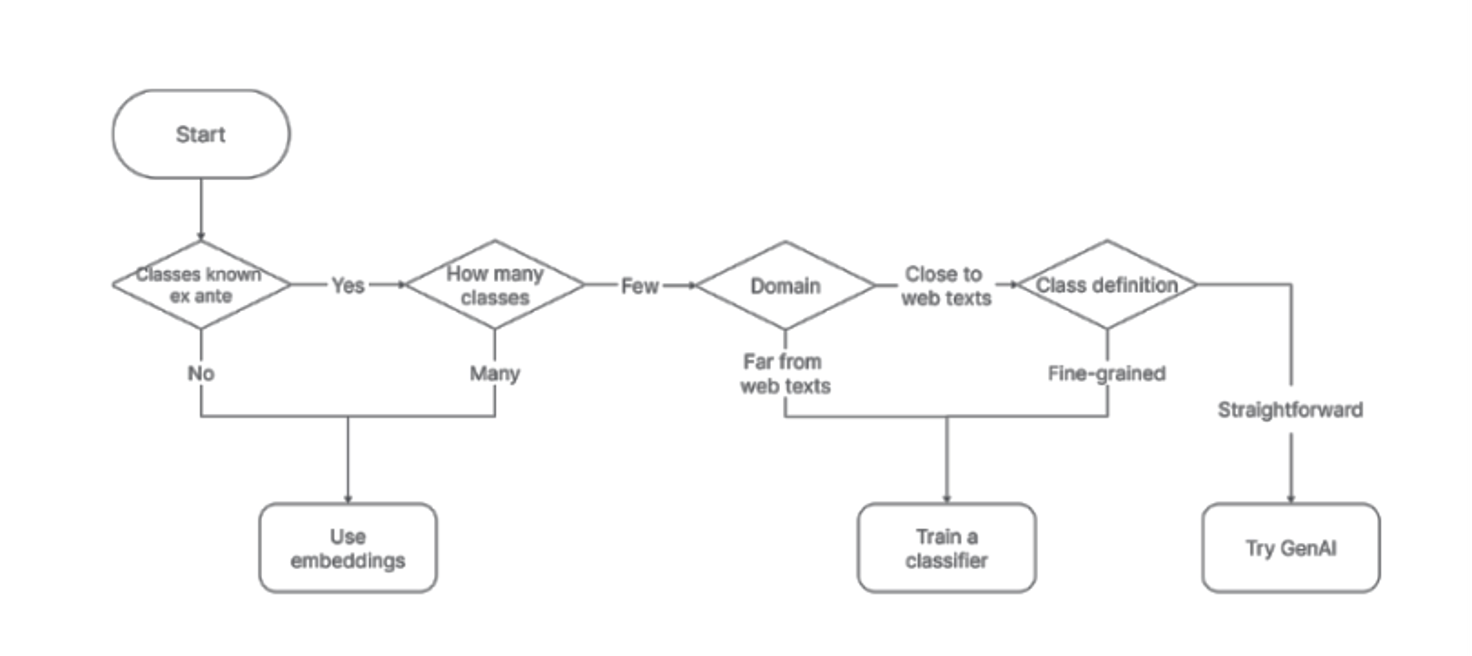

Source: Melissa Dell https://dell-research-harvard.github.io/projects.html

## Recap

<h3> Summary of the excercise </h3>

This notebook explores text classification of financial transactions, starting with data loading, cleaning, and exploratory data analysis. It then demonstrates applying traditional machine learning techniques like Random Forest with TF-IDF, addressing class imbalance with SMOTE, and experimenting with FastText for classification. Finally, it introduces the use of state-of-the-art models from HuggingFace for potential performance improvement.



<h3> Discussion questions </h3>



1.   What trade-offs do you see in
including the dominant category, and how might this influence model performance?
2.   What would you do next in this classification exercise?

3. Have you faced a similar challenge before? Can anyone share experiences with classifying imbalanced datasets or dealing with noisy or incomplete labels? How did you approach it?

3. What steps can be taken to improve the model's performance with a small sample size?

4. How would you deal with the 'Other Goods' dominant category?

5. How would you mitigate the risk of the model learning to overly predict the dominant class? Would you use re-sampling techniques or class-weight adjustments?

5.  How would the model's performance change with a larger dataset? Could adding noise or irrelevant data hurt model accuracy?



<h4> ⏩ Given the workload, can we come up with the best steps to advance with this model? </h4>